# 🛒 E-Commerce Customer Segmentation using RFM Analysis
Proyek ini bertujuan untuk mengelompokkan pelanggan (*user segmentation*) berdasarkan perilaku belanja menggunakan metode **RFM (Recency, Frequency, Monetary)**. Analisis ini membantu bisnis dalam merumuskan strategi pemasaran yang dipersonalisasi untuk meningkatkan retensi dan pendapatan.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hubungkan Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset transaksi online retail
# Pastikan path sesuai dengan lokasi file Anda di Drive
file_path = '/content/drive/My Drive/Project User Segmentation/Salinan Online Retail Data.csv'
df = pd.read_csv(file_path, header=0)

# Tampilkan 5 baris pertama data
print("Ukuran Dataset:", df.shape)
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ukuran Dataset: (461773, 7)


,order_id,product_code,product_name,quantity,order_date,price,customer_id
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0
3,493413,21724,PANDA AND BUNNIES STICKER SHEET,1,2010-01-04 09:54:00,0.85,NaN
4,493413,84578,ELEPHANT TOY WITH BLUE T-SHIRT,1,2010-01-04 09:54:00,3.75,NaN
...,...,...,...,...,...,...,...
461768,539991,21618,4 WILDFLOWER BOTANICAL CANDLES,1,2010-12-23 16:49:00,1.25,NaN
461769,539991,72741,GRAND CHOCOLATECANDLE,4,2010-12-23 16:49:00,1.45,NaN
461770,539992,21470,FLOWER VINE RAFFIA FOOD COVER,1,2010-12-23 17:41:00,3.75,NaN
461771,539992,22258,FELT FARM ANIMAL RABBIT,1,2010-12-23 17:41:00,1.25,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  object 
 1   product_code  461773 non-null  object 
 2   product_name  459055 non-null  object 
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  object 
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.7+ MB


## 🧹 Data Cleansing & Preparation
Pada tahap ini, kita membersihkan data mentah, mengubah format tanggal, dan menghitung total nilai transaksi (`amount = quantity * price`) untuk setiap baris pesanan.

In [7]:
# Salin dataframe untuk proses pembersihan
df_clean = df.copy()

# Konversi kolom tanggal order (menggunakan 'order_date' sesuai info dataframe)
df_clean['date'] = pd.to_datetime(df_clean['order_date']).dt.date.astype('datetime64[ns]')

# Hitung total nilai transaksi per baris
df_clean['amount'] = df_clean['quantity'] * df_clean['price']

# Hapus data yang tidak memiliki customer_id, atau memiliki quantity/price <= 0
df_clean = df_clean.dropna(subset=['customer_id'])
df_clean = df_clean[(df_clean['quantity'] > 0) & (df_clean['price'] > 0)]

print("Jumlah baris setelah dibersihkan:", df_clean.shape)
df_clean

Jumlah baris setelah dibersihkan: (352897, 9)


,order_id,product_code,product_name,quantity,order_date,price,customer_id,date,amount
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0,2010-01-04,22.50
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0,2010-01-04,22.50
6,493414,21844,RETRO SPOT MUG,36,2010-01-04 10:28:00,2.55,14590.0,2010-01-04,91.80
7,493414,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-04 10:28:00,4.25,14590.0,2010-01-04,51.00
8,493414,37508,NEW ENGLAND CERAMIC CAKE SERVER,2,2010-01-04 10:28:00,2.55,14590.0,2010-01-04,5.10
...,...,...,...,...,...,...,...,...,...
461740,539988,84380,SET OF 3 BUTTERFLY COOKIE CUTTERS,1,2010-12-23 16:06:00,1.25,18116.0,2010-12-23,1.25
461741,539988,84849D,HOT BATHS SOAP HOLDER,1,2010-12-23 16:06:00,1.69,18116.0,2010-12-23,1.69
461742,539988,84849B,FAIRY SOAP SOAP HOLDER,1,2010-12-23 16:06:00,1.69,18116.0,2010-12-23,1.69
461743,539988,22854,CREAM SWEETHEART EGG HOLDER,2,2010-12-23 16:06:00,4.95,18116.0,2010-12-23,9.90


In [8]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 352897 entries, 0 to 461744
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      352897 non-null  object        
 1   product_code  352897 non-null  object        
 2   product_name  352897 non-null  object        
 3   quantity      352897 non-null  int64         
 4   order_date    352897 non-null  object        
 5   price         352897 non-null  float64       
 6   customer_id   352897 non-null  float64       
 7   date          352897 non-null  datetime64[ns]
 8   amount        352897 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 26.9+ MB


## 📊 RFM Metric Aggregation
Kita mengagregasi data transaksi per pelanggan (`customer_id`) untuk mendapatkan 3 metrik utama:
1. **Recency**: Berapa hari sejak transaksi terakhir pelanggan.
2. **Frequency**: Berapa kali pelanggan melakukan transaksi/order.
3. **Monetary**: Total uang yang dibelanjakan oleh pelanggan.

In [15]:
# Tentukan tanggal acuan (today) dari transaksi paling akhir di dataset
today = df_clean['date'].max()

# Agregasi data per customer
df_user = df_clean.groupby('customer_id', as_index=False).agg(
    order_cnt=('order_id', 'nunique'),
    max_order_date=('date', 'max'),
    total_order_value=('amount', 'sum')
)

# Hitung jumlah hari sejak order terakhir
df_user['day_since_last_order'] = (today - df_user['max_order_date']).dt.days

# Buat skor Recency (skala 1-5 secara aman menggunakan qcut dengan penanganan duplikat)
try:
    df_user['recency_score'] = pd.qcut(df_user['day_since_last_order'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)
except ValueError:
    df_user['recency_score'] = pd.qcut(df_user['day_since_last_order'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)

# Buat skor Frequency secara aman
try:
    df_user['frequency_score'] = pd.qcut(df_user['order_cnt'], 5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
except ValueError:
    df_user['frequency_score'] = pd.qcut(df_user['order_cnt'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Buat skor Monetary secara aman
try:
    df_user['monetary_score'] = pd.qcut(df_user['total_order_value'], 5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
except ValueError:
    df_user['monetary_score'] = pd.qcut(df_user['total_order_value'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)

print("Berhasil menghitung skor RFM secara aman!")
df_user

Berhasil menghitung skor RFM secara aman!


,customer_id,order_cnt,max_order_date,total_order_value,day_since_last_order,recency_score,frequency_score,monetary_score
0,12346.0,6,2010-06-28,259.36,178,1,4,2
1,12608.0,1,2010-10-31,415.79,53,3,1,2
2,12745.0,2,2010-08-10,723.85,135,2,2,3
3,12746.0,1,2010-06-17,254.55,189,1,1,2
4,12747.0,14,2010-12-13,4396.24,10,5,5,5
...,...,...,...,...,...,...,...,...
3882,18283.0,6,2010-11-22,641.77,31,4,5,3
3883,18284.0,1,2010-10-04,461.68,80,2,2,2
3884,18285.0,1,2010-02-17,427.00,309,1,2,2
3885,18286.0,1,2010-08-20,833.48,125,2,2,3


## 🏷️ Customer Segmentation Labeling
Berdasarkan kombinasi skor Recency dan Frequency, kita memetakan pelanggan ke dalam 10 segmen strategis (seperti *Champion*, *Loyal Customers*, *At Risk*, *Hibernating*, dll.).

In [16]:
# Pemetaan segmen berdasarkan aturan skor R dan F
df_user['segment'] = np.select(
    [
        (df_user['recency_score'] == 5) & (df_user['frequency_score'] >= 4),
        (df_user['recency_score'].between(3, 4)) & (df_user['frequency_score'] >= 4),
        (df_user['recency_score'] >= 4) & (df_user['frequency_score'].between(2, 3)),
        (df_user['recency_score'] <= 2) & (df_user['frequency_score'] == 5),
        (df_user['recency_score'] == 3) & (df_user['frequency_score'] == 3),
        (df_user['recency_score'] == 5) & (df_user['frequency_score'] == 1),
        (df_user['recency_score'] == 4) & (df_user['frequency_score'] == 1),
        (df_user['recency_score'] <= 2) & (df_user['frequency_score'].between(3, 4)),
        (df_user['recency_score'] == 3) & (df_user['frequency_score'] <= 2),
        (df_user['recency_score'] <= 2) & (df_user['frequency_score'] <= 2)
    ],
    [
        '01-Champion', '02-Loyal Customers', '03-Potential Loyalists', '04-Can’t Lose Them',
        '05-Need Attention', '06-New Customers', '07-Promising', '08-At Risk',
        '09-About to Sleep', '10-Hibernating'
    ],
    default='Other'
)

# Hitung persentase pelanggan per segmen untuk melengkapi ringkasan
total_customers = df_user['customer_id'].nunique()

# Buat Pivot Table Summary
summary_rfm = pd.pivot_table(
    df_user,
    index='segment',
    values=['customer_id', 'day_since_last_order', 'order_cnt', 'total_order_value'],
    aggfunc={
        'customer_id': ['nunique'],
        'day_since_last_order': [np.mean, np.median],
        'order_cnt': [np.mean, np.median],
        'total_order_value': [np.mean, np.median]
    }
)

# Tambahkan kolom persentase jumlah user
summary_rfm['pct_unique'] = (summary_rfm[('customer_id', 'nunique')] / total_customers) * 100
summary_rfm = summary_rfm.sort_values(by=('pct_unique', ''), ascending=False)

summary_rfm.round(2)

/tmp/ipykernel_2013/1091615837.py:27: FutureWarning: The provided callable <function mean at 0x7d1e20f607c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  summary_rfm = pd.pivot_table(
/tmp/ipykernel_2013/1091615837.py:27: FutureWarning: The provided callable <function median at 0x7d1e209e3ba0> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  summary_rfm = pd.pivot_table(


customer_id day_since_last_order        order_cnt  \
                           nunique                 mean median      mean   
segment                                                                    
10-Hibernating                 942               199.39  200.0      1.12   
02-Loyal Customers             679                42.63   39.0      6.36   
01-Champion                    603                11.67   11.0     12.20   
08-At Risk                     528               150.10  126.0      3.00   
03-Potential Loyalists         458                25.61   27.0      1.99   
09-About to Sleep              295                60.00   59.0      1.21   
05-Need Attention              193                60.47   60.0      2.41   
07-Promising                    84                33.93   35.5      1.00   
04-Can’t Lose Them              69               123.03  113.0      8.55   
06-New Customers                36                15.11   17.0      1.00   

                              total_order_value          pct_unique  
                       median              mean   median             
segment                                                              
10-Hibernating            1.0            390.48   248.73      24.23  
02-Loyal Customers        5.0           2414.40  1634.83      17.47  
01-Champion               8.0           5914.96  2545.70      15.51  
08-At Risk                3.0           1105.34   762.28      13.58  
03-Potential Loyalists    2.0            646.05   491.52      11.78  
09-About to Sleep         1.0            415.73   314.74       7.59  
05-Need Attention         2.0           1013.25   702.96       4.97  
07-Promising              1.0            329.40   252.52       2.16  
04-Can’t Lose Them        7.0           3089.54  2160.15       1.78  
06-New Customers          1.0            251.88   235.88       0.93

## 📈 Visualisasi Proporsi Segmen Pelanggan
Visualisasi ini membantu pemangku kepentingan (*stakeholders*) melihat kelompok pelanggan mana yang mendominasi basis data perusahaan.

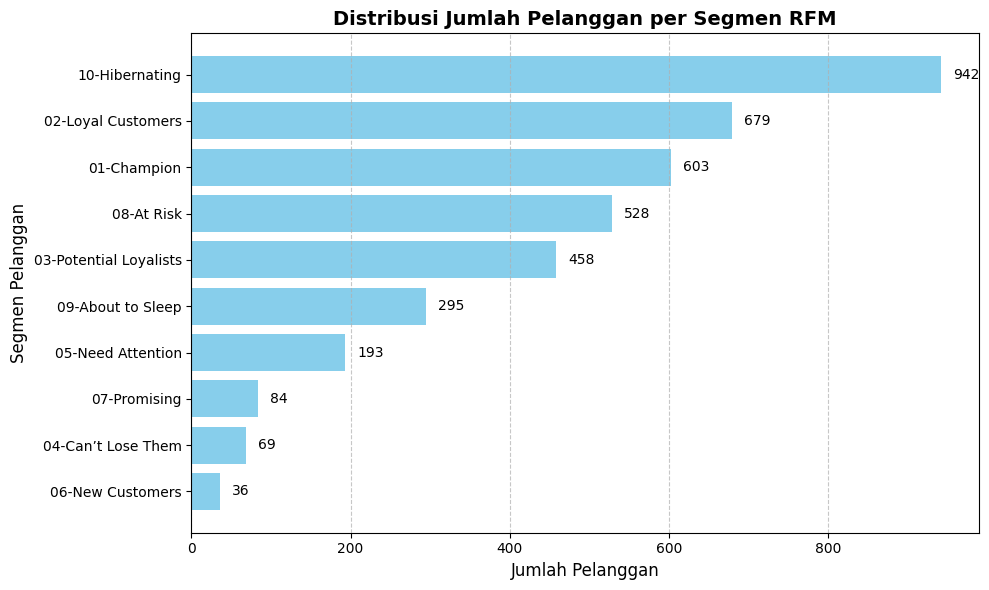

In [17]:
# Visualisasi sederhana jumlah customer per segmen
segment_counts = df_user['segment'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(segment_counts.index, segment_counts.values, color='skyblue')
plt.title('Distribusi Jumlah Pelanggan per Segmen RFM', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Pelanggan', fontsize=12)
plt.ylabel('Segmen Pelanggan', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tambahkan angka di samping bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 15, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

## 💡 Business Recommendations & Insights
Berdasarkan hasil analisis RFM, berikut adalah strategi bisnis yang dapat direkomendasikan:

1. **Champion (14.1%) & Loyal Customers (14.0%):**
   - *Strategi:* Berikan program loyalitas eksklusif, *early access* ke produk baru, atau diskon khusus VIP agar mereka tetap merasa dihargai dan tidak berpindah ke kompetitor.
2. **At Risk (11.0%) & Can't Lose Them (1.6%):**
   - *Strategi:* Pelanggan di segmen ini dulunya bernilai tinggi tetapi sudah lama tidak bertransaksi. Lakukan *win-back campaign* berupa email pengingat, penawaran diskon khusus retensi, atau survei kepuasan.
3. **Hibernating (27.3%):**
   - *Strategi:* Merupakan porsi terbesar namun pasif. Kirimkan promosi pemicu (re-engagement campaigns) dengan penawaran harga menarik untuk menarik mereka kembali melakukan pembelian pertama setelah sekian lama.

In [19]:
# Simpan hasil akhir RFM ke Google Drive agar mudah diakses Looker Studio
output_path = '/content/drive/My Drive/Project User Segmentation/rfm_customer_segments.csv'

# Export ke CSV (tanpa index agar rapi)
df_user.to_csv(output_path, index=False)

print(f"File berhasil disimpan ke: {output_path}")
print("Jumlah total customer yang tersegmentasi:", len(df_user))
df_user

File berhasil disimpan ke: /content/drive/My Drive/Project User Segmentation/rfm_customer_segments.csv
Jumlah total customer yang tersegmentasi: 3887


,customer_id,order_cnt,max_order_date,total_order_value,day_since_last_order,recency_score,frequency_score,monetary_score,segment
0,12346.0,6,2010-06-28,259.36,178,1,4,2,08-At Risk
1,12608.0,1,2010-10-31,415.79,53,3,1,2,09-About to Sleep
2,12745.0,2,2010-08-10,723.85,135,2,2,3,10-Hibernating
3,12746.0,1,2010-06-17,254.55,189,1,1,2,10-Hibernating
4,12747.0,14,2010-12-13,4396.24,10,5,5,5,01-Champion
...,...,...,...,...,...,...,...,...,...
3882,18283.0,6,2010-11-22,641.77,31,4,5,3,02-Loyal Customers
3883,18284.0,1,2010-10-04,461.68,80,2,2,2,10-Hibernating
3884,18285.0,1,2010-02-17,427.00,309,1,2,2,10-Hibernating
3885,18286.0,1,2010-08-20,833.48,125,2,2,3,10-Hibernating
